In [1]:
#import networkx as nx
import sys
import os
from tqdm import tqdm

notebookname =  'NB_250521_StatefulBandit'
current_directory_os = os.getcwd()

# Add related modules to path
sys.path.append(current_directory_os+'/'+notebookname)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from matplotlib.colors import LinearSegmentedColormap
import time

from action_scheduler import Schedule
from ResistorNetwork import makeNetwork
#from experiment import Experiment
from TaskMaker import makeDataset


### Experiment Object Local

In [3]:
from typing import Dict, Sequence, Any
import numpy as np
from action_scheduler import Schedule
from ResistorNetwork import ResistorNetwork
from tqdm import tqdm

class Experiment:
    """
    Base scaffold for an experiment run.
    
    Attributes
    ----------
    required_params : Sequence[str]
        List of parameter names that must be provided in `params`.
    schedule : Any
        Object defining the order of actions.
    DATA : np.ndarray
        Array of shape (#train + #test, #inputs + #outputs).
    IONODE : np.ndarray
        Array of shape (#inputs + #outputs,) defining node locations.
    """
    # Define here the names of all required params
    required_params: Sequence[str] = [
        "ALF", # learning rate
        "ETA", # nudge factor
        "OVC", # overclamping
        "NOR", # batch normalization (1) or adam optimizer (2)
        "DIF", # differential outputs
        "DGC", # dG (gradient) clipping
        "TRA", # number of training datapoints (also implicitly # test)
        "INP", # number of inputs (also implicitly # outputs)
        "TDS", # training data selection (0 for random, < 0 to indicate cycling with period abs(n))
        "GMN", # minimum for learning parameters
        "GMX", # maximum for learning parameters
        "FLP", # multiply this to learning steps -- fixes resistance vs capacitance
        "EPS", # for LOS==2 (Q Learning), starting fraction that a random action (datapoint) is taken (trained)
        "EPM", # for LOS==2 (Q Learning), ending fraction that a random action (datapoint) is taken (trained)
        "GAM", # for LOS==2 (Q Learning) with env state, discount factor for future estimates
        "LOS", # loss function - 0 for MSE, 1 for shifted hinge, 2 for Q learning
      #  "VMX", # maximum voltage (for use in classification loss/labeling)
      #  "VMN", # minimum voltage (for use in classification loss/labeling)
      #  "CEA", # Cross-Entropy alpha: modulates crossentropy loss magnitude to keep clamping within range
        "UDE", # update exponent
        "MXP", # MULT exponent (for overclamping)
    ]
    # to add: EQP for eqprop, 
       

    def __init__(
        self,
        params: Dict[str, Any],
        schedule: Any,
        data: np.ndarray,
        ionode: np.ndarray,
        network: ResistorNetwork
    ):


        self.beta1 = 0.6
        self.beta2 = 0.999
        self.epsilon = 1e-3
        
        self.m = np.zeros_like(network.params)
        self.v = np.zeros_like(network.params)

        self.VBD = [np.min(data),np.max(data)]
        
        # 1. Check for missing params
        missing = set(self.required_params) - set(params.keys())
        if missing:
            raise ValueError(f"Missing required params: {missing}")

        # 1. Assign params to attributes
        for name in self.required_params:
            setattr(self, name, params[name])

        # 2. Store the schedule object
        self.SCHEDULE = schedule
        self.STP = self.SCHEDULE.total_steps

        # 3. Store the data array
        #    Expect shape: (#train + #test, #inputs + #outputs)
        if not isinstance(data, np.ndarray):
            raise TypeError("`DATA` must be a numpy.ndarray")
        self.DATA = data
        self.TST = np.shape(self.DATA)[0]-self.TRA
        self.OUT = np.shape(self.DATA)[1]-self.INP
        self.MULTS = np.ones(self.TRA)/self.TRA

        # 4. Store the ionode array
        #    Expect shape: (#inputs + #outputs,)
        if not isinstance(ionode, np.ndarray):
            raise TypeError("`IONODE` must be a numpy.ndarray")
        self.IONODE = ionode
        if np.size(self.IONODE) != self.INP+self.OUT:
            raise SizeError("IONODE must have INP+OUT values, the same as axis 1 of DATA")

        self.t = -1 # not yet trained
        self.batch_step = 0

        # 5. Store the network object
        self.network = network
        self.NN = network.num_nodes
        self.NE = np.size(network.node_from)

        self.update = network.params*0.0 # store spot for learning updates

        self.stored_states = []
        self.stored_clamp_states = []
        self.stored_params = []
        self.stored_state_steps = []
        self.stored_param_steps = []
        self.stored_loss = []
        self.stored_reward = []
        self.stored_reward_std = []
        self.stored_reward_count = []
        self.rewards=[]

        self.freestates = np.zeros((self.TRA+self.TST,self.NN))
        self.clampstates = np.zeros((self.TRA,self.NN)) # no clamped state for test points

        self.sincebatch_free = np.zeros(self.TRA)
        self.sincebatch_clamped = np.zeros(self.TRA)
        
        self.QReward = None
        self.QState = None
        self.kill = False

    """ Runs the experiment! Simply iterate through actions, update internal clock"""
    def run(self,kill=None,msg='Training'):
        
        for act in self.SCHEDULE.get_actions(0):
            self.perform_action(act,0)          
        self.t = 0
        
        for t in tqdm(range(1,self.SCHEDULE.total_steps),desc=msg,total=self.SCHEDULE.total_steps):
            for act in self.SCHEDULE.get_actions(t):
                self.perform_action(act,t,kill=kill)          
            self.t = t+1
            if self.kill:
                break

    """ calculate loss for given datapoints (or their mean) based on the EXP's loss function"""
    def loss(self,datapoints=None,mean=False): 
        
        if datapoints is None:
            datapoints = np.arange(self.TRA+self.TST) # default is every datapoint

       
        outvals = self.freestates[np.ix_(datapoints, self.IONODE[self.INP:])]
        labels = self.DATA[np.ix_(datapoints,np.arange(self.INP,self.INP+self.OUT))]
 
        if self.DIF:
            outvals = outvals[:,::2]-outvals[:,1::2]
            labels = labels[:,::2]-labels[:,1::2]
        
        if self.LOS == 0: # MSE
            LOSS = np.sum((outvals-labels)**2,axis=1)
        
        elif self.LOS == 1: # Shifted Hinge
            #raise Exception('problem!')
            #LOSS = self.cross_entropy_loss(u=outvals, y=labels) 
            LOSS = np.sum((outvals-labels)**2,axis=1)
            for idx in range(len(LOSS)):
                if (np.sign(outvals[idx]-labels[idx]) == np.sign(labels[idx])):
                    LOSS[idx]  = 0


        elif self.LOS == 2: # Q Learning (discrete) -- will need something else for continuous
            LOSS = np.sum((outvals-labels)**2,axis=1)

        if mean:
            LOSS = np.mean(LOSS)

        return LOSS
        
    """ Let's actually perform these actions... """
    def perform_action(self,act,t,kill=None):

        if act == 'INIT':
            print('DOING INIT!!')
        elif act == 'TRAIN':

            if self.LOS==2:
                # step is determined from TDS value
                self.perform_train_step(self.TDS,t)
                                    
            else: # standard supervised training
                # Choose datapoint
                if self.TDS == 0:
                    train_idx = np.random.choice(self.TRA)
                elif self.TDS < 0: # corrected 5/21/25
                    train_idx = int(t//(-self.TDS)) % self.TRA
                else:
                    raise ValueError("TDS positive has no coded meaning")
                
                self.perform_train_step(train_idx)
            
        elif act == 'MEASURE': 
            datapoints = np.arange(self.TRA+self.TST) # all datapoints
            nodes = np.arange(self.NN) # every node
            values = self.measure(datapoints,nodes,clamp=False)  # measure (equilibrate)
            clampvalues = self.measure(datapoints,nodes,clamp=True)  # measure (equilibrate)
            self.stored_states.append(values) # store it
            self.stored_clamp_states.append(clampvalues) # store it
            self.stored_state_steps.append(t)
            self.stored_loss.append(self.loss(mean=False)) # store training loss
            if len(self.rewards)>0:
                self.stored_reward.append(np.mean(self.rewards))
                self.stored_reward_std.append(np.std(self.rewards))
                self.stored_reward_count.append(np.size(self.rewards))
            else:
                self.stored_reward.append(np.nan)
                self.stored_reward_std.append(np.nan)
                self.stored_reward_count.append(0)

            
            self.rewards = []
                
            if kill == 'CLASSERR0':
                if np.sum(self.stored_loss[-1]>=np.squeeze(np.diff(self.DATA[:,self.INP:],axis=1))**2)==0:
                    self.kill = True
        
        elif act == 'STOREPARAM': 
            self.store_params(t=t)  # measure it!
            
        # Apply stored update to params
        elif act == 'BATCH':
            self.apply_batch()

        # Apply stored update to params
        elif act == 'RESET':
            self.TDS = np.random.randint(self.TRA)
            
        else:
            raise ValueError("Bad Action Given: "+act)

    """ apply batched updates """
    def apply_batch(self):    
       # if G_update_scaling:
       #     update *= (network.params-GMN)

        if self.NOR==2:
            self.batch_step+=1
            self.m = self.beta1 * self.m + (1 - self.beta1) * (-self.update)
            self.v = self.beta2 * self.v + (1 - self.beta2) * (self.update**2)
    
            m_hat = self.m / (1 - self.beta1 ** self.batch_step)
            v_hat = self.v / (1 - self.beta2 ** self.batch_step)

            self.update = -m_hat / (np.sqrt(v_hat) + self.epsilon)

        if np.any(np.isnan(self.update)):
            print("nan update",self.update)
            print(self.m,self.v,self.network.params)
            raise Exception('prob')
            self.update = np.zeros_like(self.update)

        if self.DGC !=0:
            self.update = np.clip(self.update,-self.DGC,self.DGC)
            
        self.network.params = np.clip(self.network.params+self.update,self.GMN,self.GMX)
        self.update *=0
        self.sincebatch_free*=0
        self.sincebatch_clamped*=0


        
    """ take specified datapoints and nodes, store them """ 
    def measure(self,datapoints,nodes,clamp=False):
        for idx in datapoints:
            if clamp:
                self.clampstates[idx] = self.getState(idx,free=False) # equilibrate state
            else:
                self.freestates[idx] = self.getState(idx) # equilibrate state

        if clamp:
            return self.clampstates[np.ix_(datapoints,nodes)]
        else:
            return self.freestates[np.ix_(datapoints,nodes)]

    """ store learning parameters """ 
    def store_params(self,t):
        self.stored_params.append(np.array(self.network.params)) # save it    
        self.stored_param_steps.append(t)

    
    """ enforce inputs, equilibrate, measure dV, clamp, equilibrate, measure dV, calc learn time, store updates """
    def perform_train_step(self,train_idx,overall_step=None):

        # find equilibrium free state, store delta V's
        self.freestates[train_idx] = self.getState(train_idx)
        doUpdate = True
        
        if self.LOS==2: # Q learning!
            frac = overall_step/self.STP
            if np.random.rand()<((self.EPM*frac) + self.EPS*(1-frac)): # we choose a random action
                action_idx = np.random.choice(self.OUT//(1+self.DIF))
              
            else: # we choose the optimal action -- 
                outputs = np.array(self.freeOut(train_idx))
                if self.DIF>0:
                    outputs = outputs[::2]-outputs[1::2]
                    
                action_idx = np.argmax(outputs)
                

            outnode = self.IONODE[self.INP+action_idx]

            reward = self.QReward(train_idx,action_idx) # state, action
            
            self.rewards.append(reward)

            new_env_state = self.QState(train_idx,action_idx) # let environment react
            
            if new_env_state != train_idx: #otherwise already solved for
                self.freestates[new_env_state] = self.getState(new_env_state) # store response
                # there are some efficiency gains to be made here avoiding redundant calcuations


            reward += self.GAM*(np.max(self.freeOut(new_env_state))-np.mean(self.freeOut(new_env_state)))
           # reward += np.sum(self.VBD)/2                                

            label = reward#+np.mean(self.freeOut(new_env_state))

            # find desired shift, invert and divide it amongst other outputs (mean nudge = 0)
          #  shift = label-self.freeOut(train_idx)[action_idx] # difference between L and O
            labels = np.array(self.freeOut(train_idx))#-(shift/(self.OUT-1)) # shift other outputs in opposite dir.
            labels[action_idx] = label # shift key input in the desired direction

            clampOut = self.getClamps(np.array(self.freeOut(train_idx)), labels)
            
            #nodes = np.hstack([self.IONODE[:self.INP],outnode])
            voltages = np.hstack([self.DATA[train_idx,:self.INP],clampOut])
           
            
            if self.sincebatch_clamped[train_idx]:
                pass
            else:
                self.clampstates[train_idx] = self.network.solve_equilibrium(self.IONODE, voltages,initial_guess=self.clampstates[train_idx],usebounds=self.VBD)



        elif self.LOS==1: # shifted hinge
            O = np.diff(self.freeOut(train_idx))
            L = np.diff(self.DATA[train_idx,self.INP:])
            if np.sign(O-L) == np.sign(L):
                doUpdate = False
                self.clampstates[train_idx] = np.array(self.freestates[train_idx])

            else: 
            # find equilibrium clamped state for this datapoint
                self.clampstates[train_idx] = self.getState(train_idx,free=False)

        else: # MSE
            self.clampstates[train_idx] = self.getState(train_idx,free=False)

        
        
        if doUpdate: # currently always true
            Vf = np.array([self.freestates[train_idx][x]-self.freestates[train_idx][y] for x,y in zip(self.network.node_from, self.network.node_to)])
            Vc = np.array([self.clampstates[train_idx][x]-self.clampstates[train_idx][y] for x,y in zip(self.network.node_from, self.network.node_to)])
            
            # calculate learning (time) multiple
            if not self.OVC is None:
                if self.DIF and self.OUT !=2:
                    raise Exception('this isnt coded right for DIF')
                elif self.DIF:
                     self.MULTS[train_idx] = abs(np.diff(self.freeOut(train_idx)-self.DATA[train_idx,self.INP:]))
                else:
                    self.MULTS[train_idx] = np.linalg.norm(np.array([self.freestates[train_idx][i]-self.DATA[train_idx][num+self.INP] for num,i in enumerate(self.IONODE[self.INP:])]))

               
            if self.NOR==1:
                SCALE = self.MULTS[train_idx]/np.sum(self.MULTS**self.MXP)
            else:
                SCALE = 1.0
            
            # learn! (store update) ## this currently divides by ETA...
            self.update += ((self.network.params-self.GMN)**(self.UDE)) * \
                self.FLP * SCALE * (self.MULTS[train_idx] ** self.MXP) * \
                self.ALF * (Vf**2-Vc**2)  / self.ETA
        
        else: # not updating -- MULT should be 0
            self.MULTS[train_idx] = 0
            

        if self.LOS == 2: # update environment state!
            self.TDS = new_env_state
            

    """ return STORED free outputs """
    def freeOut(self,train_idx):
        return [self.freestates[train_idx][i] for i in self.IONODE[self.INP:]]

    """ SOLVE and return entire equilibrated state """
    def getState(self, train_idx,free=True):
    
        if free: 
            endidx = self.INP
        else:
            endidx = self.INP+self.OUT
        
        nodes = self.IONODE[:endidx]
        voltages = np.array(self.DATA[train_idx,:endidx])

        if not free: # change from labels to actual clamp values
            voltages[self.INP:] = self.getClamps(freeOut=self.freeOut(train_idx),labels = self.DATA[train_idx,self.INP:])

        if free:
            initial_guess = self.freestates[train_idx]
            if self.sincebatch_free[train_idx]:
                return initial_guess
            else:
                self.sincebatch_free[train_idx] = True
        else:
            initial_guess = self.clampstates[train_idx]
            if self.sincebatch_clamped[train_idx]:
                return initial_guess
            else:
                self.sincebatch_clamped[train_idx] = True
       

        return self.network.solve_equilibrium(nodes, voltages,initial_guess=initial_guess,usebounds=self.VBD)


    """ Generate clamping values given free outputs and labels (value to train towards)"""
    def getClamps(self,freeOut, labels):
      
        if self.LOS==1: # pick label for DIF + HINGE
            if self.DIF != 1 or self.OUT != 2:
                raise Exception('Hinge loss only stipulated for single dif output!')

           # clampouts = self.dynamic_ce_label(u=freeOut,y=labels)
        # keep just the labels in DATA
        
        if self.OVC is None:
            clampouts = [i for i in labels]

        else: # if overclamping, switch to OC values based on sign of error
            if self.DIF:
                clampouts = []
                doublediff = np.diff(np.array(freeOut)-np.array(labels))
                for idx in range(len(doublediff)):
                    if np.sign(doublediff[idx])<0:
                        clampouts+= self.OVC
                    else:
                        clampouts+= self.OVC[-1::-1] 
            else:
                clampouts = [self.OVC[0] if np.sign(self.OVC[0]-f)==np.sign(L-f) else self.OVC[1] for (f,L) in zip(freeOut,clampouts)]

        # apply ETA
        clamps = [f*(1-self.ETA) + self.ETA*L for (f,L) in zip(freeOut,clampouts)]

        if self.DIF: # correct clamping to mirror mean of free output
            for t in range(self.OUT//2):
                clamps[t*2:t*2+2] += self.ETA* (-np.mean(clamps[t*2:t*2+2])+np.mean(freeOut[t*2:t*2+2]))

        return clamps


        
    def dynamic_ce_label(self,
                     u: np.ndarray,
                     y: np.ndarray,
                     eps: float = 1e-7
                    ) -> np.ndarray:
        """ Compute dynamic MSE‐labels z so that
          (g - z) * dg/du = alpha * (f - y0),
        where g = VMN + R*f, f=sigmoid(u), y0=(y-VMN)/R.
        """
        # in [eps,1-eps]
        f0 = np.clip(1/(1 + np.exp(-np.array(u))), eps, 1 - eps)
        # normalize y into [0,1]
        y0 = (y - self.VMN) / (self.VMX - self.VMN)

        # SCALE the correction by alpha:
        z0 = f0 - self.CEA * (f0 - y0) / (f0 * (1 - f0))

        # back into [VMN,VMX]
        return self.VMN + (self.VMX - self.VMN) * z0


    def cross_entropy_loss(self,
                       u: np.ndarray,
                       y: np.ndarray,
                       eps: float = 1e-12
                      ) -> np.ndarray:
        """
        Returns per-sample CE loss L = -sum(y0 * log p).
        """
        # normalize targets into [0,1]
        y0           = (y - self.VMN) / (self.VMX-self.VMN)
    
        # stabilized softmax
       # shift     = u - np.max(u, axis=1, keepdims=True)
       # exp_shift = np.exp(shift)
       # p         = exp_shift / exp_shift.sum(axis=1, keepdims=True)
    
        exp_shift = np.exp(u - np.max(u, axis=1, keepdims=True))
        p         = exp_shift / exp_shift.sum(axis=1, keepdims=True)

        # cross-entropy: -sum over classes of y0 * log p
        return -np.sum(y0 * np.log(p + eps), axis=1)

    
    def cross_entropy_error(self,
                            u: np.ndarray,
                            y: np.ndarray
                           ) -> np.ndarray:
        """
        Compute delta = alpha*(p - y0), with p=softmax(u), y0=(y-VMN)/R.
        """
        # normalize y
        y0 = (y - self.VMN) / (self.VMX - self.VMN)

        # stabilized softmax
        shift     = u - np.max(u, axis=1, keepdims=True)
        exp_shift = np.exp(shift)
        p         = exp_shift / exp_shift.sum(axis=1, keepdims=True)

        # shrink the CE‐gradient by alpha
        return self.CEA * (p - y0)
        
    

## Create Network

#### Constructed DENSE network, G_MOS edges, NN = 15 , NE = 44


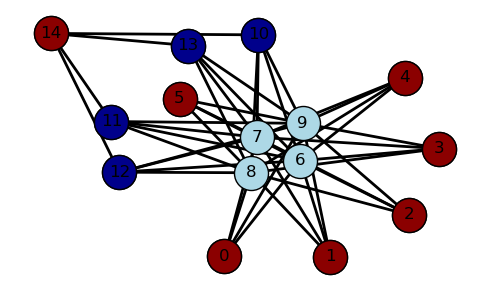

In [4]:
""" choose conduction (edge) functionality """
conduct_func, directed = 'G_MOS',False #'G_MOS_NORM', False # 'G_DIO' # 'G_DIG' # 

""" select size and architecture of network """
network_type,network_spec = 'PLATTICE',[4,4]
network_type,network_spec = 'DENSE',[6,4,4,1]


network = makeNetwork(network_type, network_spec,conduct_func, directed = directed)
network.params= network.params*0+2.0 + np.random.randn(np.size(network.params))*.05 # initialize
#network.params= network.params*0+50.0 + np.random.randn(np.size(network.params))*5 # initialize

""" select IO nodes """
a = np.sum(network_spec[:2])
b = np.sum(network_spec[:-1])
INODES, ONODES = [0,2,8,10], [7,13]
INODES, ONODES = [0,2,8,10], [5,7,13,15]
INODES, ONODES = [0,1,2,3,4,5,14], [10,11,12,13]
IONODES = np.array(INODES+ONODES).astype(int)

print("#### Constructed",network_type, "network,",conduct_func, "edges, NN =", network.num_nodes, ", NE =", len(network.node_to))
network.display_graph(directed = directed,nodegroups=[INODES,ONODES],figsize=(5,3))

### Define Task (Q Learning)

Max reward is: 0.43885167199992864


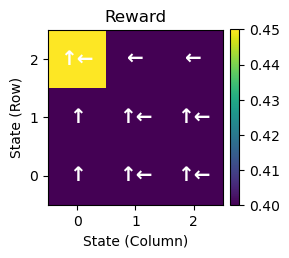

In [24]:
np.random.seed(100) 

DIF = 0 # use for differential outputs
_NOISE_SCALE = 0
_N_ARMS = len(ONODES)//(1+DIF) # Dims/2
boxlengths = [3,3]
DIMS = int(_N_ARMS/2)
_N_STATES = int(np.prod(boxlengths)) # size of box
GAM = .5 # discount factor for future states
EPS = .1 # starting epsilon
EPM = .0   # ending epsilon
shaping = 0.00001 # reward shaping magnitude
bigreward = 0.2
bigreward = 0.05
baseline = .4

RES = 5 # reset state randomly at this many steps



rowcol = lambda state: (state % boxlengths[0], state // boxlengths[0])

actual_target = np.random.randint(_N_STATES)
actual_target = 2
mat = np.zeros(tuple(boxlengths)) + baseline
mat[rowcol(actual_target)] += bigreward

row0,col0 = rowcol(actual_target)
for row in range(boxlengths[0]):
    for col in range(boxlengths[1]):
        mat[row,col] -= (abs(row0-row) + abs(col0-col))*shaping

q_true = np.zeros((_N_STATES,_N_ARMS))  # true value of the actions 
# (all zero except reaching goal)

			
actionset = ['↑','↓','←','→','o']

def QState(state, action): 

  #  if state == actual_target:
  #      outstate = actual_target
  #      while outstate == actual_target:
  #          outstate = np.random.randint(_N_STATES)
  #      return outstate

    row,col = rowcol(state)

    if action == 2: # move left
        col = (col-1) 
    elif action == 3: #move right
        col = (col+1) 
    elif action == 1: # move down
        row = (row-1)
    elif action == 0: #move up
        row = (row+1)
    elif action == 4: # stay put
        pass
    else:
        raise Exception('Bad Action!')

    row = np.min([np.max([row,0]),boxlengths[0]-1])
    col = np.min([np.max([col,0]),boxlengths[1]-1])
    
    return int(col*boxlengths[0] + row)


for s in range(_N_STATES):
    for a in range(_N_ARMS):
        q_true[s,a] = mat[rowcol(QState(s,a))]

#q_true[actual_target,:] = np.mean(q_true)

        
QReward = lambda state, action: q_true[state,action] + _NOISE_SCALE * np.random.randn(1)[0]  # obtain reward

TRA = _N_STATES
TST = 0
INP = len(INODES)

DATA = np.zeros((TRA+TST,np.size(IONODES)))

GND = 0.0
VPL = 1.0

DATA[:,0] = [(VPL-GND)*(i % boxlengths[0])/(boxlengths[0]-1) + GND for i in range(_N_STATES)]
DATA[:,1] = [(VPL-GND)*(i // boxlengths[0])/(boxlengths[0]-1) + GND for i in range(_N_STATES)]
DATA[:,2] = VPL-DATA[:,0]
DATA[:,3] = VPL-DATA[:,1]
DATA[:,2] = GND
DATA[:,3] = VPL
DATA[:,4] = (VPL+GND)/2
# fill rewards later

fig, axs = plt.subplots(1,1,figsize=(3,3))
img = axs.imshow(mat,vmin=baseline, vmax=baseline+bigreward)
axs.set_xlabel(r'State (Column)')
axs.set_ylabel(r'State (Row)');
axs.set_title('Reward')
cbar = plt.colorbar(img,fraction=0.046, pad=0.04)
plt.xticks([0,1,2])
plt.yticks([0,1,2])

axs.invert_yaxis()

for s in range(_N_STATES):
    action = ''
    for a in range(_N_ARMS):
        if q_true[s,a] == np.max(q_true[s,:]):
            action += actionset[a]
    row,col = rowcol(s)
    if len(action)==_N_ARMS:
        action = 'A'
    plt.text(col,row,action,c='w',ha='center',va='center',fontsize='x-large',fontweight='bold')

#DATA[:,len(INODES)::(1+DIF)] = q_true # assign labels as true reward matrix

plt.tight_layout()


maxreward=0
testingsteps = 10000

state = 0
for t in range(testingsteps):
    if np.random.rand(1)[0]<EPM:
        action = np.random.randint(_N_ARMS)
    else:
        action = np.argmax(q_true[state,:])
        
    maxreward+= QReward(state,action)
    state = QState(state,action)

    if t%RES == 0:
        state = np.random.randint(_N_STATES)

maxreward /= testingsteps

print("Max reward is:", maxreward)

### Specify Hyperparameters, Compile Experiment and run!

ALF: 10 || ETA: 0.1 || OVC: None || NOR: 0 || DIF: 0 || DGC: 0.1 || CLA: 1 || TRA: 9 || INP: 7 || TDS: 0 || GMN: 1 || GMX: 5.5 || FLP: 1.0 || LOS: 2 || EPS: 0.1 || EPM: 0.0 || MXP: 1 || GAM: 0.5 || UDE: 0 || 

Schedule 300000 steps
  STOREPARAM, MEASURE [step 0]
  TRAIN [every step]
  BATCH [every 50 steps]
  RESET [every 5 steps]
  STOREPARAM, MEASURE [list 1]


Training: 100%|███████████████████████▉| 299999/300000 [06:13<00:00, 803.34it/s]


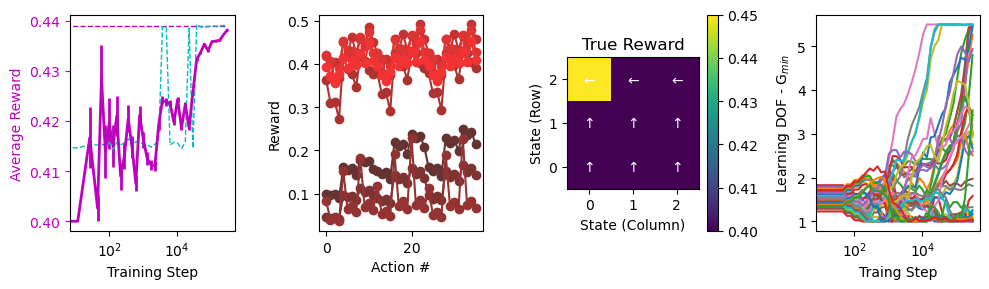

ALF: 10 || ETA: 0.1 || OVC: None || NOR: 0 || DIF: 0 || DGC: 0.1 || CLA: 1 || TRA: 9 || INP: 7 || TDS: 0 || GMN: 1 || GMX: 5.5 || FLP: 1.0 || LOS: 2 || EPS: 0.1 || EPM: 0.0 || MXP: 1 || GAM: 0.5 || UDE: 0 || 

Schedule 300000 steps
  STOREPARAM, MEASURE [step 0]
  TRAIN [every step]
  BATCH [every 50 steps]
  RESET [every 5 steps]
  STOREPARAM, MEASURE [list 1]


Training: 100%|███████████████████████▉| 299999/300000 [06:16<00:00, 796.87it/s]


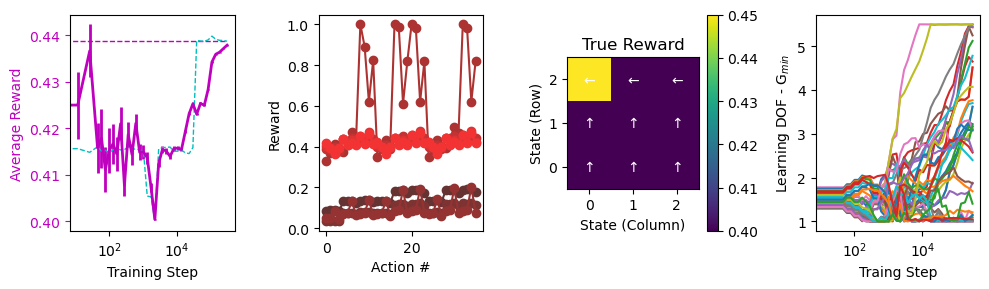

ALF: 10 || ETA: 0.1 || OVC: None || NOR: 0 || DIF: 0 || DGC: 0.1 || CLA: 1 || TRA: 9 || INP: 7 || TDS: 0 || GMN: 1 || GMX: 5.5 || FLP: 1.0 || LOS: 2 || EPS: 0.1 || EPM: 0.0 || MXP: 1 || GAM: 0.5 || UDE: 0 || 

Schedule 300000 steps
  STOREPARAM, MEASURE [step 0]
  TRAIN [every step]
  BATCH [every 50 steps]
  RESET [every 5 steps]
  STOREPARAM, MEASURE [list 1]


Training: 100%|███████████████████████▉| 299999/300000 [06:13<00:00, 802.59it/s]


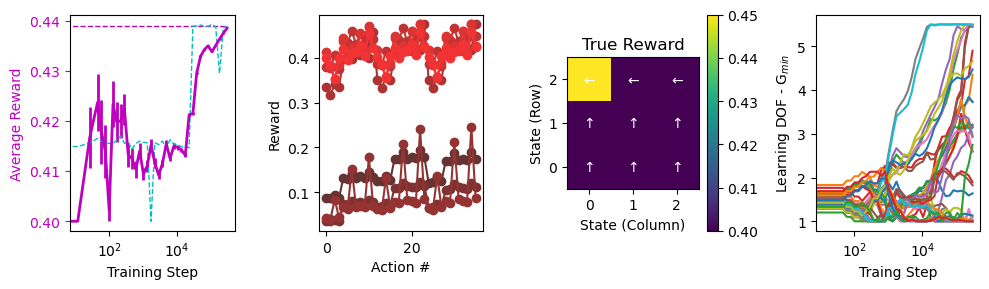

ALF: 10 || ETA: 0.1 || OVC: None || NOR: 0 || DIF: 0 || DGC: 0.1 || CLA: 1 || TRA: 9 || INP: 7 || TDS: 0 || GMN: 1 || GMX: 5.5 || FLP: 1.0 || LOS: 2 || EPS: 0.1 || EPM: 0.0 || MXP: 1 || GAM: 0.5 || UDE: 0 || 

Schedule 300000 steps
  STOREPARAM, MEASURE [step 0]
  TRAIN [every step]
  BATCH [every 50 steps]
  RESET [every 5 steps]
  STOREPARAM, MEASURE [list 1]


Training: 100%|███████████████████████▉| 299999/300000 [06:09<00:00, 813.00it/s]


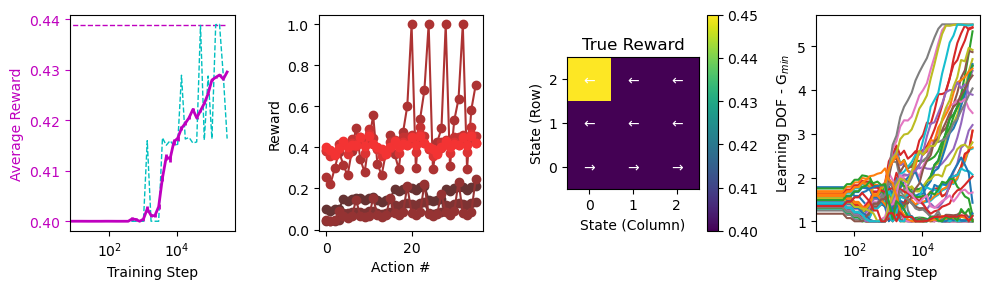

ALF: 10 || ETA: 0.1 || OVC: None || NOR: 0 || DIF: 0 || DGC: 0.1 || CLA: 1 || TRA: 9 || INP: 7 || TDS: 0 || GMN: 1 || GMX: 5.5 || FLP: 1.0 || LOS: 2 || EPS: 0.1 || EPM: 0.0 || MXP: 1 || GAM: 0.5 || UDE: 0 || 

Schedule 300000 steps
  STOREPARAM, MEASURE [step 0]
  TRAIN [every step]
  BATCH [every 50 steps]
  RESET [every 5 steps]
  STOREPARAM, MEASURE [list 1]


Training: 100%|███████████████████████▉| 299999/300000 [06:28<00:00, 771.97it/s]


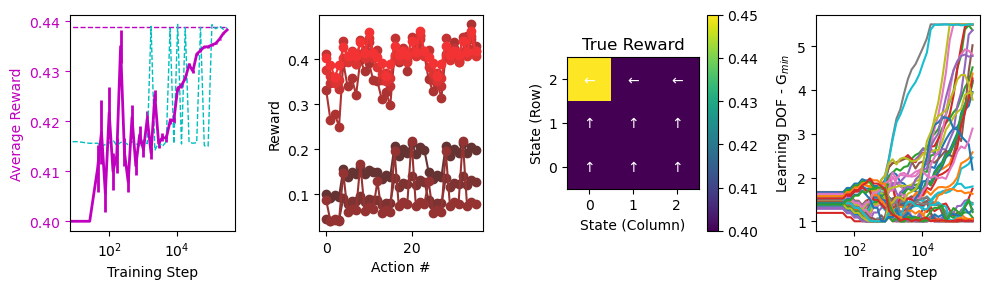

ALF: 10 || ETA: 0.1 || OVC: None || NOR: 0 || DIF: 0 || DGC: 0.1 || CLA: 1 || TRA: 9 || INP: 7 || TDS: 0 || GMN: 1 || GMX: 5.5 || FLP: 1.0 || LOS: 2 || EPS: 0.1 || EPM: 0.0 || MXP: 1 || GAM: 0.5 || UDE: 0 || 

Schedule 300000 steps
  STOREPARAM, MEASURE [step 0]
  TRAIN [every step]
  BATCH [every 50 steps]
  RESET [every 5 steps]
  STOREPARAM, MEASURE [list 1]


Training: 100%|███████████████████████▉| 299999/300000 [06:05<00:00, 821.04it/s]


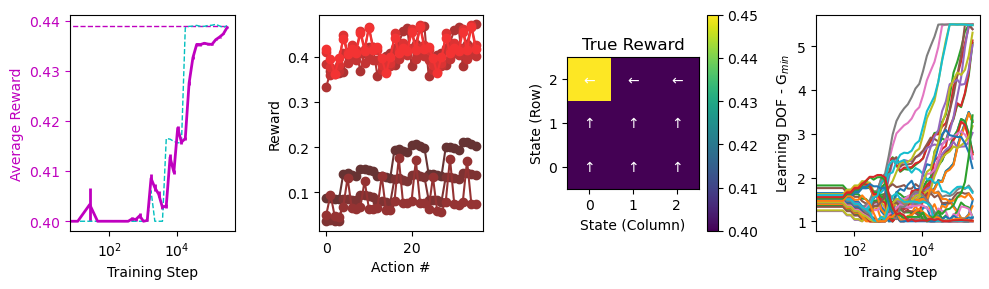

ALF: 10 || ETA: 0.1 || OVC: None || NOR: 0 || DIF: 0 || DGC: 0.1 || CLA: 1 || TRA: 9 || INP: 7 || TDS: 0 || GMN: 1 || GMX: 5.5 || FLP: 1.0 || LOS: 2 || EPS: 0.1 || EPM: 0.0 || MXP: 1 || GAM: 0.5 || UDE: 0 || 

Schedule 300000 steps
  STOREPARAM, MEASURE [step 0]
  TRAIN [every step]
  BATCH [every 50 steps]
  RESET [every 5 steps]
  STOREPARAM, MEASURE [list 1]


Training: 100%|███████████████████████▉| 299999/300000 [06:05<00:00, 821.30it/s]


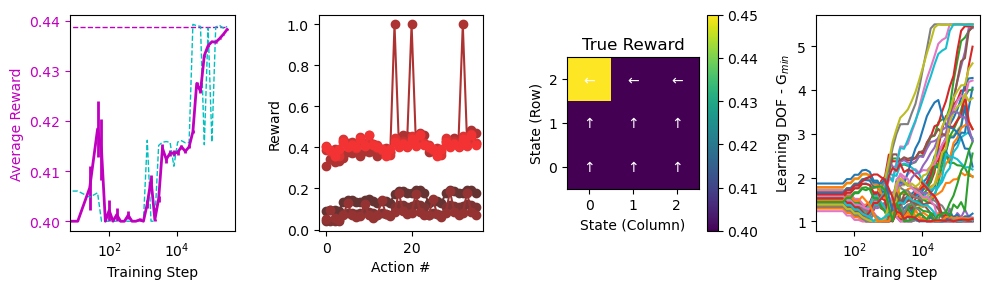

ALF: 10 || ETA: 0.1 || OVC: None || NOR: 0 || DIF: 0 || DGC: 0.1 || CLA: 1 || TRA: 9 || INP: 7 || TDS: 0 || GMN: 1 || GMX: 5.5 || FLP: 1.0 || LOS: 2 || EPS: 0.1 || EPM: 0.0 || MXP: 1 || GAM: 0.5 || UDE: 0 || 

Schedule 300000 steps
  STOREPARAM, MEASURE [step 0]
  TRAIN [every step]
  BATCH [every 50 steps]
  RESET [every 5 steps]
  STOREPARAM, MEASURE [list 1]


Training: 100%|███████████████████████▉| 299999/300000 [06:00<00:00, 831.89it/s]


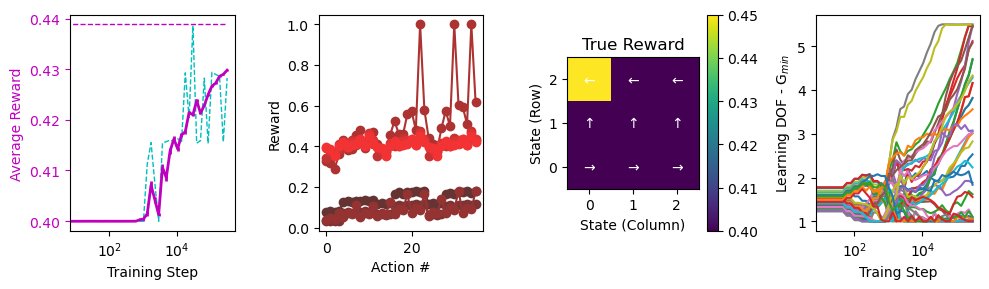

ALF: 10 || ETA: 0.1 || OVC: None || NOR: 0 || DIF: 0 || DGC: 0.1 || CLA: 1 || TRA: 9 || INP: 7 || TDS: 0 || GMN: 1 || GMX: 5.5 || FLP: 1.0 || LOS: 2 || EPS: 0.1 || EPM: 0.0 || MXP: 1 || GAM: 0.5 || UDE: 0 || 

Schedule 300000 steps
  STOREPARAM, MEASURE [step 0]
  TRAIN [every step]
  BATCH [every 50 steps]
  RESET [every 5 steps]
  STOREPARAM, MEASURE [list 1]


Training: 100%|███████████████████████▉| 299999/300000 [06:06<00:00, 818.22it/s]


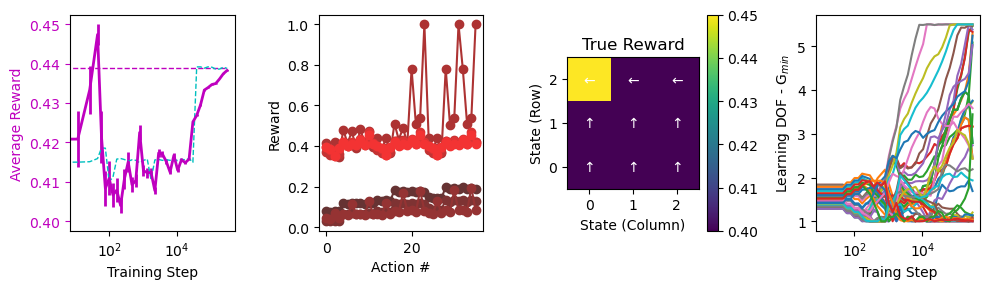

ALF: 10 || ETA: 0.1 || OVC: None || NOR: 0 || DIF: 0 || DGC: 0.1 || CLA: 1 || TRA: 9 || INP: 7 || TDS: 0 || GMN: 1 || GMX: 5.5 || FLP: 1.0 || LOS: 2 || EPS: 0.1 || EPM: 0.0 || MXP: 1 || GAM: 0.5 || UDE: 0 || 

Schedule 300000 steps
  STOREPARAM, MEASURE [step 0]
  TRAIN [every step]
  BATCH [every 50 steps]
  RESET [every 5 steps]
  STOREPARAM, MEASURE [list 1]


Training: 100%|███████████████████████▉| 299999/300000 [06:02<00:00, 827.61it/s]


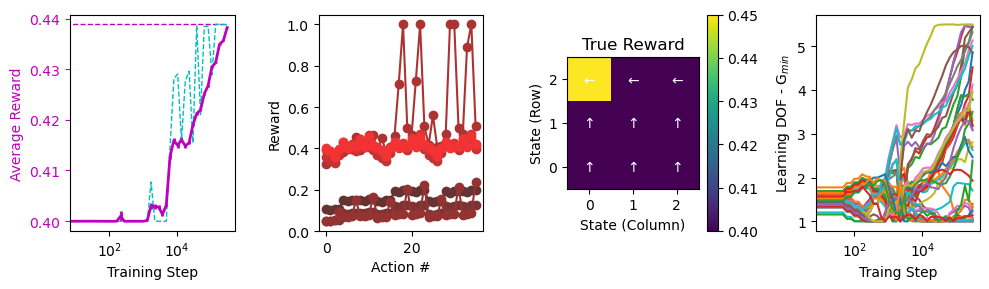

In [6]:
inits =[]
EXPs = []
alfs = [1]
alfs = [10]
for expidx in range(10):
    for alfidx in range(len(alfs)):
        np.random.seed(expidx)
        
        """ Select steps, approx (upper lim) meas count, batching rate """
        STP = 3*10**5
        MES = 50 # logarithmically spaced
        minMESdelta = 10
        BTH = 50
        
        """ define other parameters """
        params = {
                "ALF":alfs[alfidx], # learning rate
                "ETA":.1, # nudge factor
                "OVC":None, # overclamping
                "NOR":0, # batch normalization, 2 = ADAM
                "DIF":DIF, # differential outputs
                "DGC":.1, # dG (gradient) clipping
                "CLA":1, # number of classes (1 for non-classification)
                "TRA":TRA, # number of training datapoints (also implies # test w/ DATA)
                "INP":INP, # number of inputs (also implies # outputs w/ DATA or IONODE)
                "TDS":0, # training data selection (0 for random, < 0 to indicate cycling with period abs(n))
                "GMN":1,#0.5, # minimum for learning parameters
                "GMX":5.5,#99.5, # maximum for learning parameters
                "FLP":1.0, # multiply this to learning steps -- fixes resistance vs capacitance
                "LOS":2, # 2 indicates using Q reinforcement learning
                "EPS":EPS, # for QRL, starting fraction that a random action (datapoint) is taken (trained)      
                "EPM":EPM, # for QRL, min fraction that a random action (datapoint) is taken (trained)      
                "MXP": 1, # MULT exponent (for overclamping) 0 means linear cost, 1 is quadratic (normal)  
                "GAM": GAM, # for LOS==2 (Q Learning) with env state, discount factor for future estimates
                "UDE": 0#2, #update exponent  (0 is standard for conductance)
        }
        
        # GMN,GMX Values for X9C303S8I digital potentiometer (shorturl.at/mEbBy)
        
        """ Set Schedule for training/measuring """
        meas_steps = np.unique((np.logspace(-.01,np.log10(STP-1),MES)).astype(int))
        idx = 0
        while idx<len(meas_steps)-1:
            if meas_steps[idx+1]-meas_steps[idx] < minMESdelta:
                meas_steps = np.delete(meas_steps,idx+1)
            else:
                idx +=1
                
        MES = len(meas_steps) # corrected for dups
        
        index_lists = {
            1: meas_steps,  # measurement steps
        }
        actions = [
           # ['INIT', 0],        # only on step 0
            ['STOREPARAM', 0],  
            ['MEASURE', 0],
            ['TRAIN', -1],      # every step
            ['BATCH', -BTH],     # every BTH steps
            ['RESET', -RES],     # every RES steps
            ['STOREPARAM', 1],  # on specified measurement steps
            ['MEASURE', 1],     # on specified measurement steps
        ]
        
        sched = Schedule(STP, actions, index_lists)
        
        
        # summarize what's been specified
        for key,value in params.items():
            print(key+": "+str(value)+" || ",end='')
        print("\n")
        
        sched.display()
        
    
        init_random = np.random.randn(np.size(network.params))*.1
        inits.append(init_random)
        for _ in range(1):
            EXP = Experiment(params, sched, DATA, IONODES, network)
            EXP.QReward = QReward
            EXP.QState = QState
            EXP.beta1 = .6
            EXP.beta2 = .999
            EXP.epsilon = 1e-3
            EXP.network.params= network.params*0+1.5 + init_random
            
            EXP.run()
            
            fig, axs = plt.subplots(1,4,figsize=(10,3))
            #plt.plot(EXP.stored_params)
            
            for edgeidx in range(EXP.NE):
                axs[3].semilogx(EXP.stored_param_steps,[i[edgeidx] for i in EXP.stored_params])
            axs[3].set_xlabel('Traing Step')
            axs[3].set_ylabel(r'Learning DOF - G$_{min}$')
            
            MES = len(EXP.stored_state_steps)
            
            stored_states = np.array(EXP.stored_states)
            skipnum=6
            inputs = np.arange(EXP.OUT*EXP.TRA//(1+EXP.DIF))
            labels = np.copy(EXP.DATA[:,EXP.INP:])
            
            errors = []
            strategies = []

            testrewards = []
            
            for measidx in range(MES):
                outputnums = EXP.IONODE[EXP.INP:]
                if EXP.DIF:
                    outputs = -stored_states[measidx,:,outputnums[::2]]+stored_states[measidx,:,outputnums[1::2]]
                else:
                    outputs = stored_states[measidx,:,outputnums]
            
                outputs = np.transpose(outputs)
            
                strat = []
                for a in range(_N_STATES):
                    strat.append(np.argmax(outputs[a,:]))
                strategies.append(strat)

                if measidx == MES-1:
                    img2 = axs[2].imshow(mat)
                    axs[2].set_xlabel(r'State (Column)')
                    axs[2].set_ylabel(r'State (Row)');
                    axs[2].set_title('True Reward')
                    plt.colorbar(img2)
                    axs[2].invert_yaxis()
                    
                    for s in range(_N_STATES):
                        action = ''
                        for a in range(_N_ARMS):
                            if outputs[s,a] == np.max(outputs[s,:]):
                                action += actionset[a]
                        row,col = rowcol(s)
                        if len(action)==_N_ARMS:
                            action = '?'
                        axs[2].text(col,row,action,c='w',ha='center',va='center')

                        
                if measidx % skipnum == 0:#==MES-1:
                 
                    axs[1].plot(inputs,outputs.flatten(),'o-',c=[.6*measidx/MES+.4,.2,.2])
            
               # errors.append(np.mean((outputs.flatten()-q_target.flatten())**2))
                #errors.append(np.mean(EXP.stored_loss[measidx]))
                #print(np.mean(EXP.stored_loss[measidx])-np.mean((outputs-labels)**2))
                
               # axs[1].errorbar(x = inputs,y=q_target.flatten(),yerr=_NOISE_SCALE,linestyle='-', fmt='ks',ms=10,mfc='w',lw=2,zorder=-100)


                if EXP.LOS == 2:
                          
                    testreward=0
                    testingsteps = 10000
                    
                    state = 0
                    for t in range(testingsteps):
                        if np.random.rand(1)[0]<EPM:
                            action = np.random.randint(_N_ARMS)
                        else:
                            action = np.argmax(outputs[state,:])
                            
                        testreward+= QReward(state,action)
                        state = QState(state,action)
                    
                        if t%RES == 0:
                            state = np.random.randint(_N_STATES)
                    
                    testreward /= testingsteps
                    testrewards.append(testreward)
                
            axs[1].set_xlabel('Action #')
            axs[1].set_ylabel('Reward')
            
            
            # loss should be true - predicted. take norm differently to weight high/low values
            
            
            #axs[0].loglog(EXP.stored_state_steps,errors,'k-',lw=2)
          #  for n in range(_N_STATES):
          #      axs[0].semilogx(EXP.stored_state_steps,[i[n] for i in strategies],'--')
            
          #  axs[0].set_yticks(ticks=np.arange(_N_ARMS))
            
            axs[0].set_xlabel('Training Step')
           # axs[0].set_ylabel('Strategies')
           # axs[0].set_ylim([-_N_ARMS-2,_N_ARMS])
            
            
            
            if EXP.LOS==2:
                axs2 = axs[0]
                othercolor = 'm'
                exprewards = EXP.stored_reward
                rewarderrs = [i/np.sqrt(j) for i,j in zip(EXP.stored_reward_std,EXP.stored_reward_count)]
                axs2.errorbar(EXP.stored_state_steps,exprewards,fmt=othercolor+'-',lw=2,yerr=rewarderrs)
                axs2.set_ylabel('Average Reward')
                axs2.set_xscale('log')
              #  axs2.spines['right'].set_color(othercolor)
                axs2.tick_params(axis='y', colors=othercolor)
                axs2.yaxis.label.set_color(othercolor)
                axs2.semilogx(EXP.stored_state_steps,[maxreward for i in EXP.stored_state_steps],othercolor+'--',lw=1)
              #  axs2.semilogx(EXP.stored_state_steps,[np.min(rewards) for i in EXP.stored_state_steps],othercolor+'--',lw=1)
              #  rng = np.max(rewards)-np.min(rewards)
               # axs2.set_ylim([np.min(rewards)-rng*.1,np.min(rewards)+2.2*rng])
               # axs2.set_yticks(ticks = [np.min(rewards), np.max(rewards)],labels=['Worst','Best'])
               # axs2.set_ylim([np.min(rewards)-rng*.5, np.max(rewards)+rng*.5])


              
                axs2.semilogx(EXP.stored_state_steps,testrewards,'c'+'--',lw=1)

            EXPs.append(EXP)
            plt.tight_layout()
            plt.show()
            #fig.savefig(notebookname+'/17_Training_plattice_MOSFET_4x4Bandit_onehot.pdf', format='pdf', bbox_inches='tight', dpi=300);

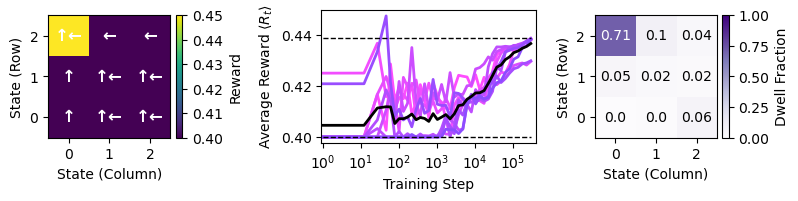

In [109]:
fig, axs = plt.subplots(1,3,figsize=(8,3), gridspec_kw={'width_ratios': [1, 1, 1]}
)

mat = np.zeros(tuple(boxlengths)) + baseline
mat[rowcol(actual_target)] += bigreward

matdensity = mat*0

row0,col0 = rowcol(actual_target)
for row in range(boxlengths[0]):
    for col in range(boxlengths[1]):
        mat[row,col] -= (abs(row0-row) + abs(col0-col))*shaping



for s in range(_N_STATES):
    action = ''
    for a in range(_N_ARMS):
        if q_true[s,a] == np.max(q_true[s,:]):
            action += actionset[a]
    row,col = rowcol(s)
    if len(action)==_N_ARMS:
        action = 'A'
    axs[0].text(col,row,action,c='w',ha='center',va='center',fontsize='large',fontweight='bold')

img = axs[0].imshow(mat,vmin=baseline, vmax=baseline+bigreward)
axs[0].set_xlabel(r'State (Column)')
axs[0].set_ylabel(r'State (Row)');
cbar = plt.colorbar(img,fraction=0.046, pad=0.04,label='Reward',ticks= np.linspace(baseline, baseline+bigreward,6))
axs[0].set_xticks([0,1,2])
axs[0].set_yticks([0,1,2])

axs[0].invert_yaxis()



#DATA[:,len(INODES)::(1+DIF)] = q_true # assign labels as true reward matrix


count = 0
rew = 0

testingsteps = 10000


for expidx,EXP in enumerate(EXPs):
    
    MES = len(EXP.stored_state_steps)
    
    stored_states = np.array(EXP.stored_states)
    inputs = np.arange(EXP.OUT*EXP.TRA)
    labels = np.copy(EXP.DATA[:,EXP.INP:])
    
    errors = []
    strategies = []
    
    ylim = r'Reward $R_t$'

    othercolor = [1-.05*expidx,.3,1]

    exprewards = EXP.stored_reward
    rew += np.array(exprewards)
    count+=1
    rewarderrs = [i/np.sqrt(j) for i,j in zip(EXP.stored_reward_std,EXP.stored_reward_count)]

    axs[1].plot(EXP.stored_state_steps,exprewards,'-',c=othercolor,lw=2)#,yerr=rewarderrs)


    outputnums = EXP.IONODE[EXP.INP:]
    if EXP.DIF:
        outputs = -stored_states[MES-1,:,outputnums[::2]]+stored_states[MES-1,:,outputnums[1::2]]
    else:
        outputs = stored_states[MES-1,:,outputnums]

    outputs = np.transpose(outputs)
          
    
    state = 0
    for t in range(testingsteps):
        if np.random.rand(1)[0]<EPM:
            action = np.random.randint(_N_ARMS)
        else:
            action = np.argmax(outputs[state,:])
            
        state = QState(state,action)
        row,col = rowcol(state)
        matdensity[row,col]+=1
        
        if t%RES == 0:
            state = np.random.randint(_N_STATES)
    

axs[1].semilogx(EXP.stored_state_steps,[maxreward for i in EXP.stored_state_steps],'k'+'--',lw=1)
axs[1].semilogx(EXP.stored_state_steps,[baseline for i in EXP.stored_state_steps],'k'+'--',lw=1)
axs[1].set_xlim([1/1.1,4*10**5])
axs[1].set_ylabel(r'Average Reward $\langle R_t \rangle$')
axs[1].set_xlabel('Training Step')
axs[1].set_xscale('log')
 
   
axs[1].plot(EXP.stored_state_steps,rew/count,'k-',lw=2,zorder=1000)
axs[1].set_xticks(ticks = np.logspace(0,5,6))


matdensity /= (testingsteps*len(EXPs))
im = axs[2].imshow(matdensity, cmap='Purples',vmin=0,vmax=1)
# tell Matplotlib “here’s the image, put the colorbar next to axs[2]”
cbar = fig.colorbar(im,
                    ax=axs[2],
                    fraction=0.046,
                    pad=0.04,
                   label="Dwell Fraction")
axs[2].set_xlabel(r'State (Column)')
axs[2].set_ylabel(r'State (Row)');

# use the OO-API for ticks and axis inversion
axs[2].set_xticks([0, 1, 2])
axs[2].set_yticks([0, 1, 2])
axs[2].invert_yaxis()

for r in range(3):
    for c in range(3):
        if matdensity[r,c]> 0.5:
            axs[2].text(c,r,str(np.round(matdensity[r,c],2)),c='w',ha='center',va='center',fontsize='medium')
        else:
            axs[2].text(c,r,str(np.round(matdensity[r,c],2)),c='k',ha='center',va='center',fontsize='medium')


plt.tight_layout()

pos = axs[1].get_position()

# build a new box: same left & width but 80% of the height
new_height = pos.height * 0.6
new_bottom = pos.y0 + (pos.height - new_height) / 2  # center it vertically

axs[1].set_position([pos.x0, new_bottom, pos.width*1.6, new_height])


fig.savefig('Fig4.pdf', format='pdf', bbox_inches='tight', dpi=300);

In [54]:
len(EXPs)

10